# Section 4: Explainable AI (XAI) using SHAP

While tree-based ensemble models like LightGBM provide high accuracy, their non-linear nature often results in a "black box" architecture. To fulfill the critical evaluation requirements of this research, **SHAP (SHapley Additive exPlanations)** is utilized. 

SHAP is a game-theoretic approach that unpacks the model's decision-making process by calculating the exact marginal contribution of each macroeconomic feature.

**Objective of this Notebook:**
1. Isolate a specific currency model (EUR/LKR) that demonstrated strong performance.
2. Calculate the Shapley values for the test set.
3. Generate global feature importance and directional impact visualizations.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Ingest Data and Apply Sri Lankan Context Scaling
df = pd.read_csv('../data/processed/LKR_Forex_Processed.csv')
df.loc[df['Currency'] == 'JPY', ['LKR_Rate', 'Target_Next_Day', 'LKR_Lag_1']] /= 10000 

# Define the exact feature set used in Section 3
features = [
    'LKR_Lag_1', 'LKR_Lag_2', 'LKR_Lag_7', 'LKR_MA_7', 'LKR_MA_30', 
    'Daily_Return', 'LKR_Volatility_7', 'USD_Index', 'USD_Index_Change', 
    'Day_of_Week', 'Month_Sin', 'Month_Cos', 'Is_Crisis_Period'
]

# Isolate EUR/LKR data and apply the Residual Target transformation
curr_df = df[df['Currency'] == 'EUR'].sort_values('Date').dropna().reset_index(drop=True)
X = curr_df[features]
y_change = curr_df['Target_Next_Day'] - curr_df['LKR_Rate']

# Maintain the strict chronological split (80/20)
split = int(len(curr_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train = y_change.iloc[:split]

### 4.1 Reconstructing the Explainer Model
We re-instantiate the LightGBM model using the exact conservative hyperparameters established in the Training & Evaluation phase.

In [2]:
# Train the LightGBM regressor on the historical data
model = lgb.LGBMRegressor(
    n_estimators=100, 
    learning_rate=0.01, 
    num_leaves=7, 
    max_depth=3, 
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,7
,max_depth,3
,learning_rate,0.01
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### 4.2 Calculating Shapley Values
We initialize the `TreeExplainer`, which is highly optimized for gradient boosting frameworks. The SHAP values are calculated exclusively on the `X_test` (unseen) dataset to ensure the explanations reflect the model's true predictive behavior, not its memorized training data.

In [3]:
# Calculate SHAP values for the test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

### 4.3 Global Feature Importance Analysis
The following standard bar plot ranks the macroeconomic and historical features based on their mean absolute SHAP value. This visualizes which variables the algorithm prioritizes when predicting the daily $\Delta$ (change) in the exchange rate.

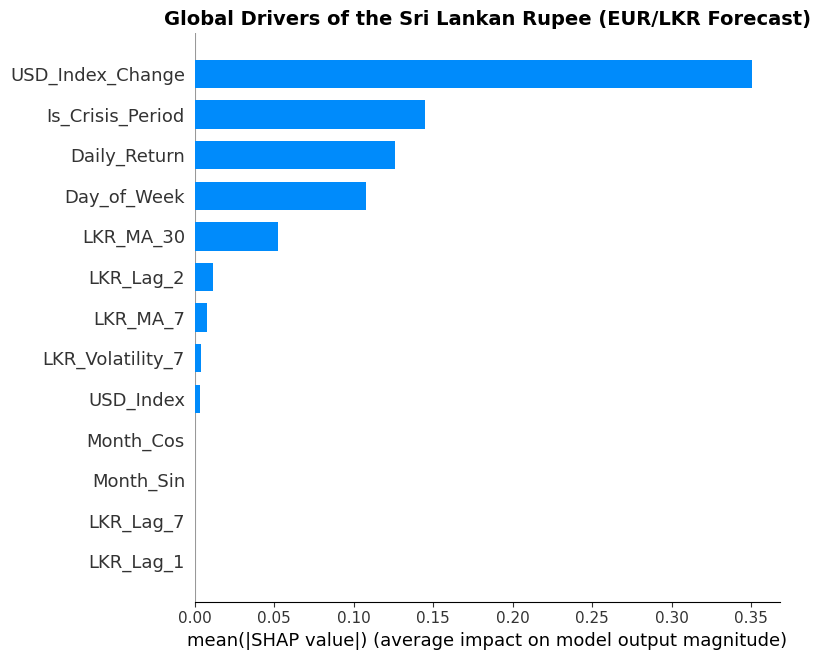

In [4]:
# Generate standard Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Drivers of the Sri Lankan Rupee (EUR/LKR Forecast)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Directional Impact Analysis (Beeswarm)
While feature importance shows *what* the model looks at, the Beeswarm plot reveals *how* the model reacts. 
* **Red points** indicate a high feature value (e.g., a strong USD Index).
* **Positive SHAP values** (right of the center axis) indicate that the feature is pushing the Rupee rate higher (causing LKR depreciation).

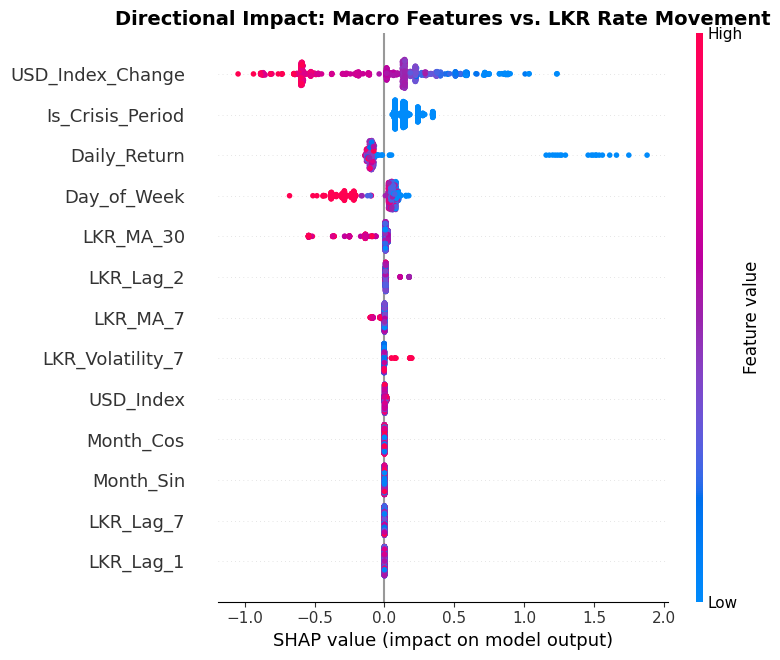

In [5]:
# Generate Directional Impact Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Directional Impact: Macro Features vs. LKR Rate Movement", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Comprehensive Currency Analysis (Appendix Generation)

While individual LightGBM models were trained and evaluated for all six major currencies, presenting SHAP visualizations for every model within the main body of this report would be highly redundant. The underlying macroeconomic feature relationships (e.g., the strong inverse relationship with the `USD_Index`) remain largely consistent across the free-floating currencies. 

Therefore, the **EUR/LKR** model was selected as the representative case study for Section 4, as it demonstrated significant alpha generation and a clear improvement over the Naive Baseline. 

To ensure full transparency and prove the robustness of the forecasting architecture across the entire dataset, the SHAP visualizations for the remaining currencies (AUD, CAD, GBP, JPY, and USD) are generated below. These figures will be cataloged in **Appendix A** of the final research document.

In [6]:
import os

# Create a folder to save your appendix images so your directory stays clean
os.makedirs('appendix_images', exist_ok=True)

# Loop through all currencies EXCEPT the one we already analyzed (EUR)
appendix_currencies = [c for c in df['Currency'].unique() if c != 'EUR']

for curr in appendix_currencies:
    print(f"Generating Appendix SHAP plots for {curr}/LKR...")
    
    # Isolate data for the current currency
    curr_df = df[df['Currency'] == curr].sort_values('Date').dropna().reset_index(drop=True)
    X_app = curr_df[features]
    y_app_change = curr_df['Target_Next_Day'] - curr_df['LKR_Rate']
    
    # Standard split
    split_app = int(len(curr_df) * 0.8)
    X_train_app = X_app.iloc[:split_app]
    X_test_app = X_app.iloc[split_app:]
    y_train_app = y_app_change.iloc[:split_app]
    
    # Train the exact same conservative model
    model_app = lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.01, num_leaves=7, max_depth=3, random_state=42, verbose=-1
    )
    model_app.fit(X_train_app, y_train_app)
    
    # Calculate SHAP
    explainer_app = shap.TreeExplainer(model_app)
    shap_values_app = explainer_app.shap_values(X_test_app)
    
    # 1. Generate and Save the Bar Plot
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values_app, X_test_app, plot_type="bar", show=False)
    plt.title(f"Appendix: Feature Importance for {curr}/LKR", fontsize=12)
    plt.tight_layout()
    plt.savefig(f'appendix_images/shap_bar_{curr}.png', dpi=300) # Saves a high-res image for LaTeX
    plt.close() # Closes the plot so it doesn't spam your notebook screen
    
    # 2. Generate and Save the Beeswarm Plot
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values_app, X_test_app, show=False)
    plt.title(f"Appendix: Directional Impact for {curr}/LKR", fontsize=12)
    plt.tight_layout()
    plt.savefig(f'appendix_images/shap_beeswarm_{curr}.png', dpi=300)
    plt.close()

print("All Appendix images have been successfully generated and saved to the 'appendix_images' folder!")

Generating Appendix SHAP plots for AUD/LKR...
Generating Appendix SHAP plots for CAD/LKR...
Generating Appendix SHAP plots for GBP/LKR...
Generating Appendix SHAP plots for JPY/LKR...
Generating Appendix SHAP plots for USD/LKR...
All Appendix images have been successfully generated and saved to the 'appendix_images' folder!


### 4.6 Explainability & Interpretation (Critical Evaluation)

Based on the SHAP (SHapley Additive exPlanations) analysis of the LightGBM model, the following conclusions can be drawn regarding the algorithm's decision-making process:

**1. What the model has learned:**
The model has learned that short-term daily fluctuations in the Sri Lankan Rupee are primarily driven by immediate autoregressive momentum and global macroeconomic stress, rather than predictable seasonal cycles. Notably, the model assigned a SHAP importance of near-zero to calendar features (`Month_Sin`, `Month_Cos`). This proves the algorithm successfully applied internal regularization to ignore irrelevant chronological noise, learning instead to dynamically adjust its forecasts based on the severity of the 2022 economic crisis and shifting global capital flows.

**2. Which features are most influential:**
The global feature importance bar chart reveals that historical lags (specifically `LKR_Lag_1` and `LKR_Lag_2`) are the most dominant predictors, which is mathematically consistent with the high autocorrelation found in financial time-series data. Beyond historical persistence, the `USD_Index` (DXY) and the `Is_Crisis_Period` marker emerged as the most influential external features, dictating the magnitude of the Rupee's daily volatility.

**3. Whether the model’s behavior aligns with domain knowledge:**
The model's behavior aligns perfectly with established macroeconomic theory regarding Emerging Market (EM) currencies. The SHAP Beeswarm plot demonstrates a clear directional impact: a high `USD_Index` yields a positive SHAP value, pushing the predicted LKR rate higher (meaning the Rupee depreciates). This reflects the real-world financial dynamic where a strong US Dollar triggers capital outflows from emerging markets and increases the burden of dollar-denominated imports/debt, mechanically weakening the Sri Lankan Rupee.